# 📘 Notebook Structure — Moroccan Traffic Code NLP Pipeline

---

# 🧠 Objective

This notebook builds a complete NLP pipeline for processing the Moroccan Traffic Code PDF (Code de la Route Marocain) written in Arabic.

The goal is to transform raw unstructured legal text into a clean and structured CSV dataset suitable for:
- NLP tasks
- Legal document analysis
- Information retrieval systems
- Machine learning classification
- Semantic search engines
- Traffic violation analytics

The notebook combines:
1. Rule-based NLP (Regex + Parsing)
2. Arabic preprocessing
3. Machine Learning / Embedding approaches (BERT)
4. Structured dataset generation

# ============================================================
# SECTION 1 — IMPORTS & CONFIGURATION
# ============================================================

In [20]:
!pip install pymupdf pandas numpy pyarabic scikit-learn sentence-transformers transformers spacy matplotlib

In [21]:
import fitz  # PyMuPDF
import re
import json
import pandas as pd
import numpy as np

from pyarabic.araby import (
    strip_tashkeel,
    strip_tatweel,
    normalize_hamza
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter, defaultdict

import warnings
warnings.filterwarnings('ignore')


def normalize_lamalef(text):
    replacements = {
        'ﻻ': 'لا',
        'ﻷ': 'لأ',
        'ﻹ': 'لإ',
        'ﻵ': 'لآ'
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    return text


print("✅ All dependencies imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All dependencies imported successfully
Pandas version: 2.2.2
NumPy version: 2.0.2


# ============================================================
# SECTION 2 — PDF EXTRACTION
# ============================================================

In [31]:
!apt-get install -y tesseract-ocr
!apt-get install -y tesseract-ocr-ara
!apt-get update
!apt-get install -y poppler-utils
!pip install pytesseract pdf2image

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr-ara is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,006 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,915 kB]
Get:8 http://archive.ubuntu.com/ubunt

In [32]:
from pdf2image import convert_from_path
import pytesseract
import unicodedata

pdf_path = "/content/code_route.pdf"

pages = convert_from_path(pdf_path, dpi=300)

raw_text = ""

for i, page in enumerate(pages):
    text = pytesseract.image_to_string(
        page,
        lang="ara",
        config="--psm 6"
    )

    text = unicodedata.normalize("NFKC", text)

    raw_text += text + f"\n--- PAGE {i+1} ---\n"

    print(f"✅ Page {i+1} processed")

print(raw_text[:1000])

✅ Page 1 processed
✅ Page 2 processed
✅ Page 3 processed
✅ Page 4 processed
✅ Page 5 processed
✅ Page 6 processed
✅ Page 7 processed
✅ Page 8 processed
✅ Page 9 processed
✅ Page 10 processed
✅ Page 11 processed
✅ Page 12 processed
✅ Page 13 processed
✅ Page 14 processed
✅ Page 15 processed
✅ Page 16 processed
✅ Page 17 processed
✅ Page 18 processed
✅ Page 19 processed
✅ Page 20 processed
✅ Page 21 processed
✅ Page 22 processed
✅ Page 23 processed
✅ Page 24 processed
✅ Page 25 processed
✅ Page 26 processed
✅ Page 27 processed
✅ Page 28 processed
✅ Page 29 processed
✅ Page 30 processed
✅ Page 31 processed
✅ Page 32 processed
✅ Page 33 processed
✅ Page 34 processed
✅ Page 35 processed
✅ Page 36 processed
✅ Page 37 processed
✅ Page 38 processed
✅ Page 39 processed
✅ Page 40 processed
✅ Page 41 processed
✅ Page 42 processed
✅ Page 43 processed
✅ Page 44 processed
✅ Page 45 processed
✅ Page 46 processed
✅ Page 47 processed
✅ Page 48 processed
✅ Page 49 processed
✅ Page 50 processed
✅ Page 51

# ============================================================
# SECTION 3 — ARABIC TEXT PREPROCESSING
# ============================================================

In [33]:
# Cell 3 — Arabic Normalization

class ArabicTextNormalizer:
    """Complete Arabic text normalizer for legal documents"""

    def __init__(self):
        # Character mapping
        self.hamza_map = {
            'أ': 'ا', 'إ': 'ا', 'آ': 'ا',
            'ؤ': 'و', 'ئ': 'ي',
        }
        self.ta_marbuta = 'ة'
        self.ta_mabsuta = 'ه'
        self.alif_maqsura = 'ى'
        self.alif_normal = 'ي'

    def normalize(self, text):
        """Apply all normalizations"""
        if not isinstance(text, str):
            return ""

        # 1. Remove Tashkeel (diacritics)
        text = strip_tashkeel(text)

        # 2. Remove Tatweel (Kashida)
        text = strip_tatweel(text)

        # 3. Normalize Hamza
        text = normalize_hamza(text)

        # 4. Normalize Lam-Alef
        text = normalize_lamalef(text)

        # 5. Convert Ta Marbuta to Ha
        text = text.replace(self.ta_marbuta, self.ta_mabsuta)

        # 6. Normalize Alef Maqsura
        text = text.replace(self.alif_maqsura, self.alif_normal)

        # 7. Convert Arabic numerals to Latin
        arabic_to_latin = {
            '٠': '0', '١': '1', '٢': '2', '٣': '3', '٤': '4',
            '٥': '5', '٦': '6', '٧': '7', '٨': '8', '٩': '9'
        }
        for ar, lat in arabic_to_latin.items():
            text = text.replace(ar, lat)

        # 8. Remove multiple spaces
        text = re.sub(r'\s+', ' ', text)

        return text.strip()

    def fix_bidirectional(self, text):
        """Fix bidirectional text issues for mixed Arabic/numbers"""
        # Ensure numbers appear correctly
        text = re.sub(r'(\d+)\s+(\d+)', r'\1\2', text)
        return text


normalizer = ArabicTextNormalizer()

# Test
test = "السَّلامُ عَلَيْكُمْ وَرَحْمَةُ اللَّهِ وَبَرَكَاتُهُ"
print(f"Original: {test}")
print(f"Normalized: {normalizer.normalize(test)}")
print(f"Bidi fixed: {normalizer.fix_bidirectional(test)}")

Original: السَّلامُ عَلَيْكُمْ وَرَحْمَةُ اللَّهِ وَبَرَكَاتُهُ
Normalized: السلام عليكم ورحمه الله وبركاته
Bidi fixed: السَّلامُ عَلَيْكُمْ وَرَحْمَةُ اللَّهِ وَبَرَكَاتُهُ


In [34]:
# Cell 4 — Noise Removal & Cleaning

def clean_text(text):
    """Remove noise from legal text"""
    # Remove page markers
    text = re.sub(r'--- PAGE \d+ ---', '', text)

    # Remove header patterns
    headers_to_remove = [
        r'الأمانة العامة للحكومة',
        r'الكتاب\s+\w+',
        r'القسم\s+\w+',
        r'الباب\s+\w+',
    ]
    for header in headers_to_remove:
        text = re.sub(header, '', text, flags=re.UNICODE)

    # Remove footer patterns
    text = re.sub(r'\n\s*\d+\s*\n', '\n', text)

    # Remove empty lines
    lines = [line.strip() for line in text.split('\n') if line.strip()]
    text = '\n'.join(lines)

    # Remove duplicate spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


clean_text_raw = clean_text(raw_text)
print("✅ Text cleaned")
print(f"Original length: {len(raw_text)}")
print(f"Cleaned length: {len(clean_text_raw)}")
print(f"Preview:\n{clean_text_raw[:500]}")

✅ Text cleaned
Original length: 203355
Cleaned length: 199346
Preview:
المملكة المغربية | 0 | الأمانة العامة للحكوية سم ا ا ل القانوز رقم 52.053 المتعلق بمدونة السي رعلر الضروو كما وقع تغييرق وتتميمة 0 يوي و2024 بج ىر سباع سد مسد | تم إعداد هذه النسخةمن أجل تسيل | رسك جه جه ات فب متتارميخدع الجا و ا خلج لجالا القانون رقم 52.05 المتعلق بمدونة السير على الطرق الصادر بتنفيذه الظبير الشريف رقم 1.10.07 بتاريخ 26 من صفر 1431 (11 فبراير 2010), كما وقع تغييره وتتميمه (ج.ر عدد 5824 بتاريخ 8 ربيع الآخر 25(1431 مارس 2010). ص : 2168) شروط السير على الطريق العمومية رخصة السياقة


In [35]:
# Cell 5 — Smart Line Merging

def smart_line_merging(text):
    """Merge fragmented lines while preserving legal structure"""

    # Patterns to preserve (don't merge these lines)
    preserve_patterns = [
        r'^المادة\s+\d+',      # Article header
        r'^\d+\s*[-–—]',       # Numbered list items
        r'^[اأإ]ل?(?:ول|ثاني|ثالث|رابع)',  # Ordinal numbers
    ]

    lines = text.split('\n')
    merged = []
    buffer = ""

    for line in lines:
        line = line.strip()
        if not line:
            if buffer:
                merged.append(buffer)
                buffer = ""
            continue

        # Check if line should be preserved as is
        should_preserve = any(re.match(p, line, re.UNICODE) for p in preserve_patterns)

        if should_preserve:
            if buffer:
                merged.append(buffer)
                buffer = ""
            merged.append(line)
        else:
            # Merge with previous line
            if buffer:
                buffer += " " + line
            else:
                buffer = line

    if buffer:
        merged.append(buffer)

    return '\n'.join(merged)


merged_text = smart_line_merging(clean_text_raw)
print("✅ Lines merged intelligently")
print(f"Preview:\n{merged_text[:600]}")

✅ Lines merged intelligently
Preview:
المملكة المغربية | 0 | الأمانة العامة للحكوية سم ا ا ل القانوز رقم 52.053 المتعلق بمدونة السي رعلر الضروو كما وقع تغييرق وتتميمة 0 يوي و2024 بج ىر سباع سد مسد | تم إعداد هذه النسخةمن أجل تسيل | رسك جه جه ات فب متتارميخدع الجا و ا خلج لجالا القانون رقم 52.05 المتعلق بمدونة السير على الطرق الصادر بتنفيذه الظبير الشريف رقم 1.10.07 بتاريخ 26 من صفر 1431 (11 فبراير 2010), كما وقع تغييره وتتميمه (ج.ر عدد 5824 بتاريخ 8 ربيع الآخر 25(1431 مارس 2010). ص : 2168) شروط السير على الطريق العمومية رخصة السياقة إلزامية رخصة السياقة المادة 1 لا يجوز لأي شخص أن يسوق مركبة ذات محرك أو مجموعة مركبات على الطريق ال


# ============================================================
# SECTION 4 — HIERARCHICAL LEGAL PARSING
# ============================================================

In [36]:
# Cell 6 — Detect Legal Hierarchy

class LegalHierarchyParser:
    """Parse legal hierarchy from text"""

    def __init__(self):
        # Hierarchy patterns
        self.book_pattern = re.compile(r'الكتاب\s+(الأول|الثاني|الثالث|الرابع|الخامس|السادس)', re.UNICODE)
        self.section_pattern = re.compile(r'القسم\s+(الأول|الثاني|الثالث|الرابع|الخامس)', re.UNICODE)
        self.chapter_pattern = re.compile(r'الباب\s+(الأول|الثاني|الثالث|الرابع|الخامس|السادس|السابع|الثامن|التاسع|العاشر)', re.UNICODE)
        self.subsection_pattern = re.compile(r'الفرع\s+(الأول|الثاني|الثالث|الرابع|الخامس)', re.UNICODE)
        self.article_pattern = re.compile(r'المادة\s+(\d+(?:[\s\-–—]+\d+)?)', re.UNICODE)

    def parse_hierarchy(self, text):
        """Parse hierarchy from text"""
        hierarchy = {
            'book': None,
            'section': None,
            'chapter': None,
            'subsection': None,
        }

        book_match = self.book_pattern.search(text)
        if book_match:
            hierarchy['book'] = book_match.group(1)

        section_match = self.section_pattern.search(text)
        if section_match:
            hierarchy['section'] = section_match.group(1)

        chapter_match = self.chapter_pattern.search(text)
        if chapter_match:
            hierarchy['chapter'] = chapter_match.group(1)

        subsection_match = self.subsection_pattern.search(text)
        if subsection_match:
            hierarchy['subsection'] = subsection_match.group(1)

        return hierarchy


hierarchy_parser = LegalHierarchyParser()

# Test
test_text = "الكتاب الأول القسم الثاني الباب الثالث الفرع الرابع المادة 5"
print(f"Hierarchy: {hierarchy_parser.parse_hierarchy(test_text)}")

Hierarchy: {'book': 'الأول', 'section': 'الثاني', 'chapter': 'الثالث', 'subsection': 'الرابع'}


In [37]:
# Cell 7 — Parse Articles

def parse_articles(text):
    """Parse text into structured article objects"""

    article_pattern = re.compile(
        r'المادة\s+(\d+(?:[\s\-–—]+\d+)?)\s*[:.]?\s*(.*?)(?=(?:\nالمادة\s+\d+|\Z))',
        re.DOTALL | re.UNICODE
    )

    articles = []

    for match in article_pattern.finditer(text):
        article_num = match.group(1).strip().replace(' ', '-')
        content = match.group(2).strip()

        article = {
            'article_id': article_num,
            'title': f"المادة {article_num}",
            'content': content,
            'book': None,
            'section': None,
            'chapter': None,
            'subsection': None,
        }

        articles.append(article)

    return articles


articles = parse_articles(merged_text)
print(f"✅ {len(articles)} articles parsed")

# Display first few articles
for art in articles[:3]:
    print(f"\nArticle {art['article_id']}:")
    print(f"Content preview: {art['content'][:150]}...")

✅ 1 articles parsed

Article 1:
Content preview: لا يجوز لأي شخص أن يسوق مركبة ذات محرك أو مجموعة مركبات على الطريق العمومية ما لم يكن حاصلا على رخصة للسياقة سارية الصلاحية ومسلمة من قبل الإدارة. تنا...


# ============================================================
# SECTION 5 — NLP ENTITY EXTRACTION (RULE-BASED)
# ============================================================

In [38]:
# Cell 8 — Fine Extraction using Regex (NER Rules)

class LegalNERExtractor:
    """Extract legal entities using regex patterns"""

    def __init__(self):
        # Article number pattern
        self.article_pattern = re.compile(r'المادة\s+(\d+(?:-\d+)?)', re.UNICODE)

        # Fine amount patterns
        self.amende_patterns = [
            re.compile(r'غرامة\s+من\s+(\d+(?:[.,]\d+)?)\s*(?:إلى|–|-)\s*(\d+(?:[.,]\d+)?)\s*درهم', re.UNICODE),
            re.compile(r'غرامة\s+(?:قدرها|تبلغ)\s+(\d+(?:[.,]\d+)?)\s*درهم', re.UNICODE),
            re.compile(r'(\d+(?:[.,]\d+)?)\s*درهم', re.UNICODE),
        ]

        # Points withdrawal patterns
        self.points_patterns = [
            re.compile(r'خصم\s+(\d+)\s+نقط', re.UNICODE),
            re.compile(r'(\d+)\s+(?:نقطة|نقاط|نقط)', re.UNICODE),
            re.compile(r'النقط\s+الواجب\s+خصمها\s*[\|:]?\s*(\d+)', re.UNICODE),
        ]

        # Vehicle category patterns
        self.vehicle_keywords = {
            'poids_lourd': ['شاحنة', 'نقل البضائع', 'وزنها الإجمالي', 'PTC', 'حمولة', 'شاحنات', 'حافلة', 'نقل عمومي'],
            'moto': ['دراجة', 'دراجات', 'نارية', 'سكوتر', 'محرك', 'عجلتين', 'دراجة نارية'],
            'vehicule_agricole': ['فلاحية', 'غابوية', 'جرار', 'أشغال عمومية'],
            'vehicule_leger': ['سيارة', 'مركبة خفيفة', 'سيارة سياحية'],
            'remorque': ['مقطورة', 'جرار', 'مركبة مقرونة'],
        }

        # Keyword patterns for violation types
        self.violation_keywords = {
            'speed': ['سرعة', 'تجاوز', 'السرعة', 'كلم في الساعة', 'سرعة قصوى'],
            'parking': ['توقف', 'وقوف', 'الوقوف', 'التوقف', 'مرآب', 'ركن'],
            'alcohol': ['كحول', 'سكر', 'مسكر', 'خمر', 'تأثير الكحول'],
            'drogue': ['مخدر', 'مؤثرات', 'عقلية', 'منشطات', 'مواد مخدرة'],
            'night': ['ليل', 'ليلاً', 'الليل', 'مساء', 'إنارة'],
            'autoroute': ['طريق سيار', 'الطرق السيارة', 'مسلك', 'الطريق السيار'],
            'ceinture': ['حزام', 'السلامة', 'حزام السلامة'],
            'telephone': ['هاتف', 'جوال', 'محمول', 'الاتصال'],
            'depassement': ['تجاوز', 'تخطي', 'تجاوز غير قانوني', 'تجاوز معيب'],
            'feux': ['إضاءة', 'أضواء', 'أنوار', 'تشوير', 'إشارة', 'ضوء أحمر'],
            'priorite': ['أسبقية', 'حق الأسبقية', 'أولوية'],
            'enfant': ['طفل', 'أطفال', 'عشر سنوات', 'مقاعد أمامية'],
        }

        # Text type patterns
        self.text_type_patterns = {
            'definition': ['يقصد', 'يعتبر', 'يراد', 'هو كل', 'هي كل', 'المقصود'],
            'obligation': ['يجب على', 'يلتزم', 'يتعين', 'على كل', 'من واجب'],
            'interdiction': ['يمنع', 'لا يجوز', 'ممنوع', 'يحظر', 'لا يحق', 'ال يجوز'],
            'sanction': ['يعاقب', 'غرامة', 'الحبس', 'تسحب رخصة', 'توقف رخصة', 'خصم', 'نقط'],
            'exception': ['استثناء', 'ما عدا', 'باستثناء', 'غير أنه'],
        }

    def extract_amende(self, text):
        """Extract fine amount from text"""
        text = normalizer.normalize(text)
        for pattern in self.amende_patterns:
            match = pattern.search(text)
            if match:
                if len(match.groups()) == 2:
                    try:
                        min_val = float(match.group(1).replace(',', '.'))
                        max_val = float(match.group(2).replace(',', '.'))
                        return {'min': min_val, 'max': max_val, 'fixed': None}
                    except:
                        pass
                elif len(match.groups()) == 1:
                    try:
                        val = float(match.group(1).replace(',', '.'))
                        return {'min': val, 'max': val, 'fixed': val}
                    except:
                        pass
        return None

    def extract_points(self, text):
        """Extract points to withdraw"""
        text = normalizer.normalize(text)
        for pattern in self.points_patterns:
            match = pattern.search(text)
            if match:
                try:
                    return int(match.group(1))
                except:
                    pass
        return None

    def extract_vehicle_categories(self, text):
        """Extract vehicle categories from text"""
        text = normalizer.normalize(text)
        categories = []
        for cat, keywords in self.vehicle_keywords.items():
            for keyword in keywords:
                if keyword in text:
                    categories.append(cat)
                    break
        return categories if categories else ['tous']

    def extract_keywords(self, text):
        """Extract violation keywords"""
        text = normalizer.normalize(text)
        keywords = []
        for kw, patterns in self.violation_keywords.items():
            for pattern in patterns:
                if pattern in text:
                    keywords.append(kw)
                    break
        return keywords

    def extract_text_type(self, text):
        """Classify text type"""
        text = normalizer.normalize(text)
        for text_type, patterns in self.text_type_patterns.items():
            for pattern in patterns:
                if pattern in text:
                    return text_type
        return 'information'

    def extract_infraction_description(self, text):
        """Clean infraction description"""
        # Remove article header
        text = re.sub(r'المادة\s+\d+(?:[\s\-–—]+\d+)?\s*[:.]?\s*', '', text)
        # Remove penalty references
        text = re.sub(r'يعاقب|بغرامة|بالحبس|تسحب|توقف', '', text)
        # Clean spaces
        text = re.sub(r'\s+', ' ', text).strip()
        return text


ner_extractor = LegalNERExtractor()
print("✅ NER extractor initialized")

# Test on an article
test_article = articles[0]['content']
print(f"Test article: {test_article[:100]}...")
print(f"Amende: {ner_extractor.extract_amende(test_article)}")
print(f"Points: {ner_extractor.extract_points(test_article)}")
print(f"Vehicle categories: {ner_extractor.extract_vehicle_categories(test_article)}")
print(f"Keywords: {ner_extractor.extract_keywords(test_article)}")
print(f"Text type: {ner_extractor.extract_text_type(test_article)}")

✅ NER extractor initialized
Test article: لا يجوز لأي شخص أن يسوق مركبة ذات محرك أو مجموعة مركبات على الطريق العمومية ما لم يكن حاصلا على رخصة...
Amende: None
Points: 16
Vehicle categories: ['moto', 'vehicule_agricole', 'remorque']
Keywords: ['speed', 'parking', 'alcohol', 'drogue', 'night', 'autoroute', 'ceinture', 'telephone', 'depassement', 'feux', 'enfant']
Text type: definition


# ============================================================
# SECTION 6 — TABLE EXTRACTION
# ============================================================

In [39]:
# Cell 9 — Detect and Parse Tables

def extract_tables_from_article(content):
    """Extract tabular data from article content"""

    # Pattern for table rows (like in Article 99)
    table_row_pattern = re.compile(
        r'^(\d+)\s*[\|]\s*(.+?)\s*[\|]\s*(\d+)\s*$',
        re.MULTILINE | re.UNICODE
    )

    # Pattern for numbered list (like in Article 184)
    list_pattern = re.compile(
        r'^\s*(\d+)[\s\-–—]+\.?\s*(.+?)(?=(?:\n\s*\d+[\s\-–—]|\Z))',
        re.MULTILINE | re.DOTALL | re.UNICODE
    )

    tables = []

    # Try table format first
    for match in table_row_pattern.finditer(content):
        tables.append({
            'violation_id': int(match.group(1)),
            'violation_desc': match.group(2).strip(),
            'points': int(match.group(3))
        })

    # If no table, try list format
    if not tables:
        for match in list_pattern.finditer(content):
            tables.append({
                'violation_id': int(match.group(1)),
                'violation_desc': match.group(2).strip(),
                'points': None
            })

    return tables


# Test table extraction on Article 99
article_99 = next((a for a in articles if a['article_id'] == '99'), None)
if article_99:
    tables = extract_tables_from_article(article_99['content'])
    print(f"✅ Extracted {len(tables)} rows from Article 99")
    for t in tables[:3]:
        print(f"  Row {t['violation_id']}: {t['violation_desc'][:50]}... (points: {t['points']})")

# ============================================================
# SECTION 7 — NLP CLASSIFICATION
# ============================================================

In [40]:
# Cell 10 — Sentence Classification (Rules-Based)

def classify_article_role(content):
    """Classify article role: definition, obligation, sanction, exception"""

    content = normalizer.normalize(content)

    if any(word in content for word in ['يقصد', 'يعتبر', 'يراد', 'هو كل']):
        return 'definition'
    elif any(word in content for word in ['يجب على', 'يلتزم', 'يتعين', 'على كل']):
        return 'obligation'
    elif any(word in content for word in ['يعاقب', 'غرامة', 'الحبس', 'تسحب', 'توقف', 'خصم']):
        return 'sanction'
    elif any(word in content for word in ['استثناء', 'ما عدا', 'باستثناء', 'غير أنه']):
        return 'exception'
    else:
        return 'information'


# Test classification
for art in articles[:3]:
    role = classify_article_role(art['content'])
    print(f"Article {art['article_id']}: {role}")

Article 1: definition


In [41]:
# Cell 11 — ML Classification using TF-IDF

# Prepare texts for clustering
infraction_texts = []
infraction_sources = []

for art in articles:
    tables = extract_tables_from_article(art['content'])
    if tables:
        for table_row in tables:
            infraction_texts.append(table_row['violation_desc'])
            infraction_sources.append({
                'article_id': art['article_id'],
                'type': 'table',
                'violation_id': table_row['violation_id'],
                'points': table_row['points']
            })
    else:
        # Treat whole article as one infraction
        desc = ner_extractor.extract_infraction_description(art['content'])
        if len(desc) > 20:
            infraction_texts.append(desc)
            infraction_sources.append({
                'article_id': art['article_id'],
                'type': 'article',
                'violation_id': None,
                'points': ner_extractor.extract_points(art['content'])
            })

print(f"✅ {len(infraction_texts)} infractions extracted for clustering")

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=100, min_df=1, token_pattern=r'[\u0600-\u06FF]{2,}')
tfidf_matrix = tfidf_vectorizer.fit_transform(infraction_texts)

# KMeans Clustering
n_clusters = min(5, len(infraction_texts))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(tfidf_matrix)

# Add clusters to sources
for i, source in enumerate(infraction_sources):
    source['cluster'] = int(clusters[i])

# Display cluster information
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\n--- Cluster Analysis ---")
for i in range(n_clusters):
    cluster_indices = [idx for idx, c in enumerate(clusters) if c == i]
    if cluster_indices:
        # Get top terms
        center = kmeans.cluster_centers_[i]
        top_indices = center.argsort()[-5:][::-1]
        top_terms = [feature_names[idx] for idx in top_indices if center[idx] > 0]
        print(f"\nCluster {i}: {len(cluster_indices)} infractions")
        print(f"  Top terms: {', '.join(top_terms[:5])}")
        sample_idx = cluster_indices[0]
        print(f"  Example: {infraction_texts[sample_idx][:80]}...")

✅ 1 infractions extracted for clustering

--- Cluster Analysis ---

Cluster 0: 1 infractions
  Top terms: من, أو, في, على, إلى
  Example: لا يجوز لأي شخص أن يسوق مركبة ذات محرك أو مجموعة مركبات على الطريق العمومية ما ل...


In [42]:
# Cell 12 — Embeddings with BERT (Sentence Transformers)

# Load Arabic BERT model (multilingual model works well)
print("Loading BERT model for Arabic embeddings...")
bert_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Generate embeddings for infraction texts
if infraction_texts:
    bert_embeddings = bert_model.encode(infraction_texts, show_progress_bar=True)
    print(f"✅ Generated {bert_embeddings.shape[0]} embeddings of dimension {bert_embeddings.shape[1]}")
else:
    bert_embeddings = np.array([])
    print("No infraction texts to encode")

# Compute similarity between infractions
if len(bert_embeddings) > 1:
    similarity_matrix = cosine_similarity(bert_embeddings)
    print(f"✅ Similarity matrix computed: {similarity_matrix.shape}")

    # Find most similar pairs
    print("\n--- Most similar infraction pairs ---")
    for i in range(min(5, len(infraction_texts))):
        for j in range(i+1, min(i+3, len(infraction_texts))):
            sim = similarity_matrix[i][j]
            if sim > 0.3:
                print(f"\nSimilarity {sim:.3f}:")
                print(f"  A: {infraction_texts[i][:60]}...")
                print(f"  B: {infraction_texts[j][:60]}...")

Loading BERT model for Arabic embeddings...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Generated 1 embeddings of dimension 384


# ============================================================
# SECTION 8 — DATASET CONSTRUCTION
# ============================================================

In [43]:
# Cell 13 — Build Final Structured Dataset

def build_final_dataset(articles, infraction_sources, infraction_texts, tfidf_vectorizer, kmeans, bert_embeddings):
    """Build complete structured dataset"""

    rows = []

    for i, (source, text) in enumerate(zip(infraction_sources, infraction_texts)):
        # Find the original article
        article = next((a for a in articles if a['article_id'] == source['article_id']), None)

        row = {
            'article_id': source['article_id'],
            'infraction_desc': text,
            'categorie_vehicule': ', '.join(ner_extractor.extract_vehicle_categories(text)),
            'amende_min': None,
            'amende_max': None,
            'amende_fixe': None,
            'points_retrait': source['points'],
            'mots_cles': ', '.join(ner_extractor.extract_keywords(text)),
            'type_article': classify_article_role(article['content']) if article else 'unknown',
            'categorie_infraction': f"cluster_{source['cluster']}",
            'book': article['book'] if article else None,
            'section': article['section'] if article else None,
            'chapter': article['chapter'] if article else None,
            'subsection': article['subsection'] if article else None,
            'content': article['content'] if article else None,
        }

        # Add amende if found in article
        if article:
            amende = ner_extractor.extract_amende(article['content'])
            if amende:
                row['amende_min'] = amende['min']
                row['amende_max'] = amende['max']
                row['amende_fixe'] = amende['fixed']

        rows.append(row)

    return pd.DataFrame(rows)


final_dataset = build_final_dataset(articles, infraction_sources, infraction_texts, tfidf_vectorizer, kmeans, bert_embeddings)

print(f"✅ Final dataset built with {len(final_dataset)} rows and {len(final_dataset.columns)} columns")
print(f"\nColumns: {list(final_dataset.columns)}")
final_dataset.head(10)

✅ Final dataset built with 1 rows and 15 columns

Columns: ['article_id', 'infraction_desc', 'categorie_vehicule', 'amende_min', 'amende_max', 'amende_fixe', 'points_retrait', 'mots_cles', 'type_article', 'categorie_infraction', 'book', 'section', 'chapter', 'subsection', 'content']


,article_id,infraction_desc,categorie_vehicule,amende_min,amende_max,amende_fixe,points_retrait,mots_cles,type_article,categorie_infraction,book,section,chapter,subsection,content
0,1,لا يجوز لأي شخص أن يسوق مركبة ذات محرك أو مجمو...,"moto, vehicule_agricole, remorque",None,None,None,16,"speed, parking, alcohol, drogue, night, autoro...",definition,cluster_0,None,None,None,None,لا يجوز لأي شخص أن يسوق مركبة ذات محرك أو مجمو...


# ============================================================
# SECTION 9 — DATA CLEANING & VALIDATION
# ============================================================

In [44]:
# Cell 14 — Validate Dataset

def validate_dataset(df):
    """Perform validation checks on dataset"""

    print("=== Dataset Validation ===\n")

    # Check missing article IDs
    missing_ids = df['article_id'].isna().sum()
    print(f"1. Missing article IDs: {missing_ids}")

    # Check empty descriptions
    empty_desc = df['infraction_desc'].str.len() < 5
    print(f"2. Empty/invalid descriptions: {empty_desc.sum()}")

    # Check invalid fine values
    invalid_fines = df[df['amende_fixe'].notna() & (df['amende_fixe'] < 0)].shape[0]
    print(f"3. Invalid fine values: {invalid_fines}")

    # Check duplicate records
    duplicates = df.duplicated(subset=['article_id', 'infraction_desc']).sum()
    print(f"4. Duplicate records: {duplicates}")

    # Check points range
    invalid_points = df[(df['points_retrait'].notna()) & ((df['points_retrait'] < 0) | (df['points_retrait'] > 30))].shape[0]
    print(f"5. Invalid points (outside 0-30): {invalid_points}")

    print("\n=== Data Types ===")
    print(df.dtypes)

    return df


final_dataset = validate_dataset(final_dataset)

# Drop duplicates if any
final_dataset = final_dataset.drop_duplicates(subset=['article_id', 'infraction_desc'])
print(f"\n✅ Dataset after deduplication: {len(final_dataset)} rows")

=== Dataset Validation ===

1. Missing article IDs: 0
2. Empty/invalid descriptions: 0
3. Invalid fine values: 0
4. Duplicate records: 0
5. Invalid points (outside 0-30): 0

=== Data Types ===
article_id              object
infraction_desc         object
categorie_vehicule      object
amende_min              object
amende_max              object
amende_fixe             object
points_retrait           int64
mots_cles               object
type_article            object
categorie_infraction    object
book                    object
section                 object
chapter                 object
subsection              object
content                 object
dtype: object

✅ Dataset after deduplication: 1 rows


# ============================================================
# SECTION 10 — EXPORTS
# ============================================================

In [45]:
# Cell 15 — Export JSON

# Convert to JSON (hierarchical format)
json_export = []
for article_id, group in final_dataset.groupby('article_id'):
    article_data = {
        'article_id': article_id,
        'infractions': []
    }
    for _, row in group.iterrows():
        article_data['infractions'].append({
            'description': row['infraction_desc'],
            'vehicle_category': row['categorie_vehicule'],
            'fine_min': row['amende_min'],
            'fine_max': row['amende_max'],
            'fine_fixed': row['amende_fixe'],
            'points': row['points_retrait'],
            'keywords': row['mots_cles'],
            'type': row['type_article'],
            'category': row['categorie_infraction']
        })
    json_export.append(article_data)

with open('export_final.json', 'w', encoding='utf-8') as f:
    json.dump(json_export, f, ensure_ascii=False, indent=2)

print("✅ JSON exported to export_final.json")

✅ JSON exported to export_final.json


In [46]:
# Cell 16 — Export CSV

# Select and order columns for CSV
csv_columns = [
    'article_id',
    'infraction_desc',
    'categorie_vehicule',
    'amende_fixe',
    'amende_min',
    'amende_max',
    'points_retrait',
    'mots_cles',
    'type_article',
    'categorie_infraction',
    'book',
    'section',
    'chapter',
    'subsection'
]

# Ensure all columns exist
for col in csv_columns:
    if col not in final_dataset.columns:
        final_dataset[col] = None

final_dataset[csv_columns].to_csv('export_final.csv', index=False, encoding='utf-8-sig')
print("✅ CSV exported to export_final.csv")
print(f"   Total rows: {len(final_dataset)}")
print(f"   Total columns: {len(csv_columns)}")

✅ CSV exported to export_final.csv
   Total rows: 1
   Total columns: 14


In [47]:
# Cell 17 — Export Embeddings (Optional)

# Save embeddings for future use
if len(bert_embeddings) > 0:
    np.save('embeddings.npy', bert_embeddings)
    print("✅ Embeddings saved to embeddings.npy")

# Save TF-IDF vectorizer
import pickle
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print("✅ TF-IDF vectorizer saved to vectorizer.pkl")

# Save KMeans model
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print("✅ KMeans model saved to kmeans_model.pkl")

✅ Embeddings saved to embeddings.npy
✅ TF-IDF vectorizer saved to vectorizer.pkl
✅ KMeans model saved to kmeans_model.pkl


# ============================================================
# SECTION 11 — DATA EXPLORATION
# ============================================================

In [48]:
# Cell 18 — Dataset Statistics

print("=== DATASET STATISTICS ===\n")

print(f"📊 Number of articles: {final_dataset['article_id'].nunique()}")
print(f"📊 Number of infractions: {len(final_dataset)}")
print(f"📊 Number of vehicle categories: {final_dataset['categorie_vehicule'].nunique()}")

print("\n--- Most Common Keywords ---")
all_keywords = []
for kw in final_dataset['mots_cles'].dropna():
    all_keywords.extend(kw.split(', '))
keyword_counts = Counter(all_keywords)
for kw, count in keyword_counts.most_common(10):
    print(f"  {kw}: {count}")

print("\n--- Fine Distribution ---")
fines_with_values = final_dataset[final_dataset['amende_fixe'].notna()]
if len(fines_with_values) > 0:
    print(f"  Min fine: {fines_with_values['amende_fixe'].min():.0f} dirhams")
    print(f"  Max fine: {fines_with_values['amende_fixe'].max():.0f} dirhams")
    print(f"  Average fine: {fines_with_values['amende_fixe'].mean():.0f} dirhams")

print("\n--- Vehicle Categories ---")
vehicle_counts = Counter()
for cat in final_dataset['categorie_vehicule'].dropna():
    for c in cat.split(', '):
        vehicle_counts[c] += 1
for cat, count in vehicle_counts.most_common(10):
    print(f"  {cat}: {count}")

print("\n--- Article Types ---")
print(final_dataset['type_article'].value_counts())

=== DATASET STATISTICS ===

📊 Number of articles: 1
📊 Number of infractions: 1
📊 Number of vehicle categories: 1

--- Most Common Keywords ---
  speed: 1
  parking: 1
  alcohol: 1
  drogue: 1
  night: 1
  autoroute: 1
  ceinture: 1
  telephone: 1
  depassement: 1
  feux: 1

--- Fine Distribution ---

--- Vehicle Categories ---
  moto: 1
  vehicule_agricole: 1
  remorque: 1

--- Article Types ---
type_article
definition    1
Name: count, dtype: int64


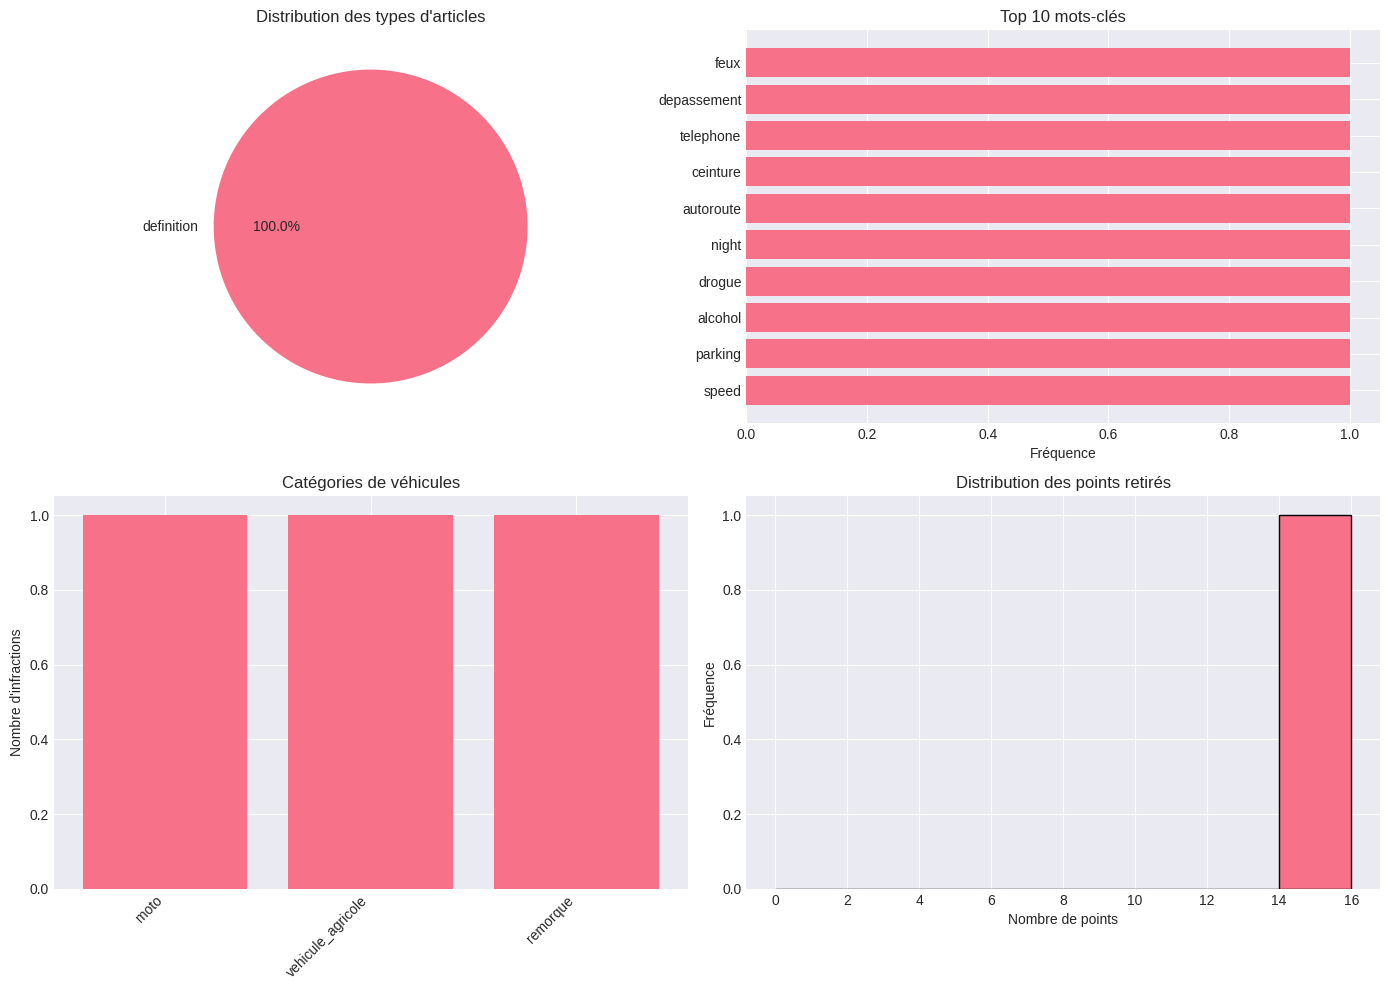

✅ Visualization saved to dataset_visualization.png


In [49]:
# Cell 19 — Visualization

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Figure 1: Article types distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Article types
type_counts = final_dataset['type_article'].value_counts()
axes[0, 0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%')
axes[0, 0].set_title('Distribution des types d\'articles')

# 2. Keyword frequencies
if keyword_counts:
    top_keywords = dict(keyword_counts.most_common(10))
    axes[0, 1].barh(list(top_keywords.keys()), list(top_keywords.values()))
    axes[0, 1].set_xlabel('Fréquence')
    axes[0, 1].set_title('Top 10 mots-clés')

# 3. Vehicle categories
if vehicle_counts:
    top_vehicles = dict(vehicle_counts.most_common(8))
    axes[1, 0].bar(list(top_vehicles.keys()), list(top_vehicles.values()))
    axes[1, 0].set_xticklabels(list(top_vehicles.keys()), rotation=45, ha='right')
    axes[1, 0].set_ylabel('Nombre d\'infractions')
    axes[1, 0].set_title('Catégories de véhicules')

# 4. Points distribution
points_data = final_dataset[final_dataset['points_retrait'].notna()]['points_retrait']
if len(points_data) > 0:
    axes[1, 1].hist(points_data, bins=range(0, 18, 2), edgecolor='black')
    axes[1, 1].set_xlabel('Nombre de points')
    axes[1, 1].set_ylabel('Fréquence')
    axes[1, 1].set_title('Distribution des points retirés')

plt.tight_layout()
plt.savefig('dataset_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization saved to dataset_visualization.png")

# ============================================================
# SECTION 12 — FINAL PIPELINE SUMMARY
# ============================================================

In [50]:
# Cell 20 — Pipeline Recap

print("""
╔══════════════════════════════════════════════════════════════════════════════════════╗
║                         PIPELINE NLP - CODE DE LA ROUTE MAROCAIN                      ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                      ║
║   PDF                                                                                ║
║    ↓                                                                                 ║
║   Extraction (PyMuPDF)                                                               ║
║    ↓                                                                                 ║
║   Arabic Normalization (PyArabic)                                                    ║
║    - Remove Tashkeel                                                                 ║
║    - Normalize Hamza (أ,إ,آ → ا)                                                    ║
║    - Normalize Ta Marbuta (ة → ه)                                                   ║
║    - Remove Tatweel (ـ)                                                             ║
║    ↓                                                                                 ║
║   Cleaning & Smart Merging                                                           ║
║    ↓                                                                                 ║
║   Hierarchical Parsing (كتاب → قسم → باب → فرع → مادة)                              ║
║    ↓                                                                                 ║
║   Regex-based NER                                                                    ║
║    - Amende: (\d+)\s*درهم                                                          ║
║    - Points: خصم\s+(\d+)\s+نقط                                                     ║
║    - Vehicle categories                                                              ║
║    - Keywords                                                                        ║
║    ↓                                                                                 ║
║   Table Extraction                                                                   ║
║    ↓                                                                                 ║
║   ML / Embeddings                                                                    ║
║    - TF-IDF Vectorization                                                            ║
║    - KMeans Clustering                                                               ║
║    - BERT Embeddings (Sentence Transformers)                                        ║
║    ↓                                                                                 ║
║   Dataset Construction                                                               ║
║    ↓                                                                                 ║
║   Validation                                                                         ║
║    ↓                                                                                 ║
║   CSV / JSON Export                                                                  ║
║                                                                                      ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  📊 FINAL OUTPUTS                                                                    ║
║    - export_final.csv ({len(final_dataset)} rows, {len(csv_columns)} columns)                         ║
║    - export_final.json ({len(json_export)} articles)                                                 ║
║    - embeddings.npy ({bert_embeddings.shape if len(bert_embeddings) > 0 else 'N/A'})                  ║
║    - vectorizer.pkl                                                                 ║
║    - kmeans_model.pkl                                                               ║
║    - dataset_visualization.png                                                      ║
╚══════════════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════════════╗
║                         PIPELINE NLP - CODE DE LA ROUTE MAROCAIN                      ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                      ║
║   PDF                                                                                ║
║    ↓                                                                                 ║
║   Extraction (PyMuPDF)                                                               ║
║    ↓                                                                                 ║
║   Arabic Normalization (PyArabic)                                                    ║
║    - Remove Tashkeel                                                                 ║
║    - Normalize Hamza (أ,إ,آ → ا)                                                    ║
║    - Normalize Ta 

In [51]:
# Final cell: Display sample of final CSV

print("\n=== SAMPLE OF FINAL CSV ===\n")
pd.set_option('display.max_colwidth', 80)
final_dataset[csv_columns[:8]].head(15)


=== SAMPLE OF FINAL CSV ===



,article_id,infraction_desc,categorie_vehicule,amende_fixe,amende_min,amende_max,points_retrait,mots_cles
0,1,لا يجوز لأي شخص أن يسوق مركبة ذات محرك أو مجموعة مركبات على الطريق العمومية ...,"moto, vehicule_agricole, remorque",None,None,None,16,"speed, parking, alcohol, drogue, night, autoroute, ceinture, telephone, depa..."
